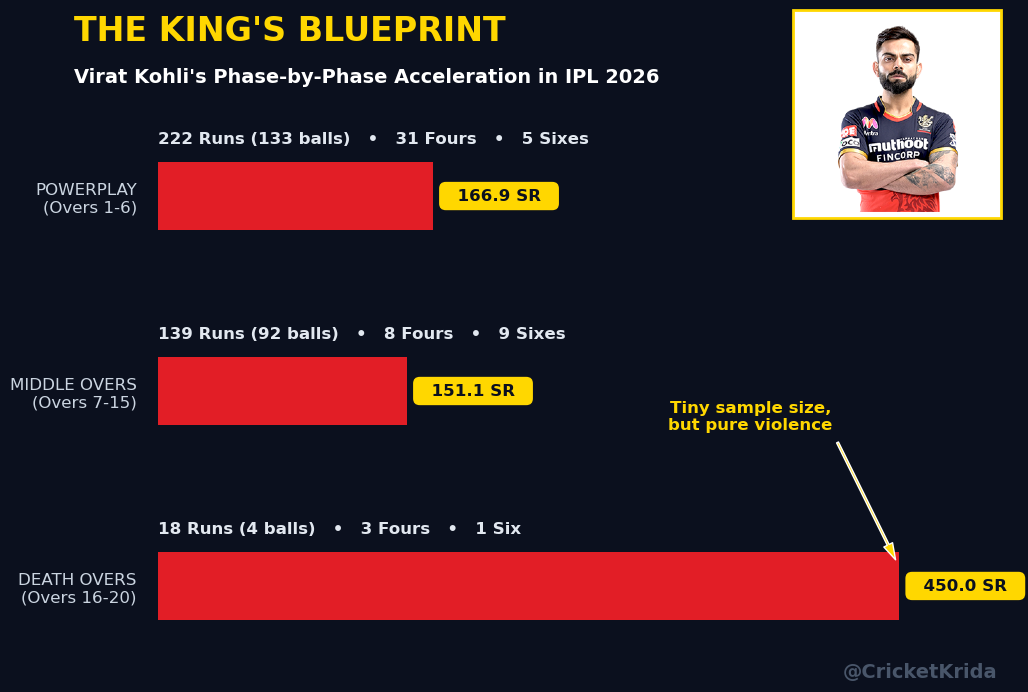

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import os

# 1. Load the Data
data = {
    'phase': ['POWERPLAY\n(Overs 1-6)', 'MIDDLE OVERS\n(Overs 7-15)', 'DEATH OVERS\n(Overs 16-20)'],
    'strike_rate': [166.9, 151.1, 450.0],
    'details': ['222 Runs (133 balls)   •   31 Fours   •   5 Sixes',
                '139 Runs (92 balls)   •   8 Fours   •   9 Sixes',
                '18 Runs (4 balls)   •   3 Fours   •   1 Six']
}

df = pd.DataFrame(data)
df = df.iloc[::-1].reset_index(drop=True)

# 2. Setup Premium Plot
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(12, 7))

# Deep rich background
bg_color = '#0B101E' 
fig.patch.set_facecolor(bg_color) 
ax.set_facecolor(bg_color)

ax.grid(axis='x', color='#1E293B', linestyle=':', linewidth=1.5, zorder=0)

# 3. Create the Bars
bar_color = '#E21E26' 
text_gold = '#FFD700' 
bars = ax.barh(df['phase'], df['strike_rate'], color=bar_color, height=0.35, zorder=3)

# 4. Annotations
for i, bar in enumerate(bars):
    width = bar.get_width()
    y = bar.get_y()
    height = bar.get_height()
    
    # Detailed Stats above the bar
    ax.text(0, y + height + 0.08, df['details'][i], 
            color='#E2E8F0', fontsize=12, fontweight='bold', ha='left', va='bottom')
    
    # Strike Rate badge
    ax.text(width + 8, y + height/2, f"  {width:.1f} SR  ", 
            va='center', color='#0B101E', fontsize=12, fontweight='900',
            bbox=dict(facecolor=text_gold, edgecolor='none', boxstyle='round,pad=0.4'))

# Highlight annotation
ax.annotate('Tiny sample size,\nbut pure violence', 
            xy=(450, 0.1), xytext=(360, 0.8),
            arrowprops=dict(facecolor=text_gold, shrink=0.05, width=1.5, headwidth=7),
            fontsize=12, color=text_gold, fontweight='bold', ha='center')

# ==========================================
# 5. ADDING THE PLAYER AVATAR
# ==========================================
player_name = "V Kohli"

# Check for either .png or .jpg
img_path = None
if os.path.exists(f"{player_name}.png"):
    img_path = f"{player_name}.png"
elif os.path.exists(f"{player_name}.jpg"):
    img_path = f"{player_name}.jpg"

if img_path:
    try:
        # Load image
        arr_img = plt.imread(img_path)
        
        # Create an OffsetImage (zoom controls the size of the image on the chart)
        # Adjust zoom=0.2 if the image is too big or too small!
        imagebox = OffsetImage(arr_img, zoom=0.5) 
        imagebox.image.axes = ax
        
        # Place the image in the top right corner of the plot
        # The coordinates (0.88, 1.05) represent (X, Y) relative to the axes
        ab = AnnotationBbox(imagebox, (0.88, 1.05), 
                            xycoords='axes fraction', 
                            frameon=True, 
                            bboxprops=dict(edgecolor=text_gold, linewidth=2)) # Gives it a nice gold border
        ax.add_artist(ab)
    except Exception as e:
        print(f"Could not load image: {e}")

# ==========================================

# 6. Premium Typography & Titles
fig.text(0.13, 0.96, "THE KING'S BLUEPRINT", 
         color=text_gold, fontsize=24, fontweight='900', fontfamily='sans-serif')

fig.text(0.13, 0.90, "Virat Kohli's Phase-by-Phase Acceleration in IPL 2026", 
         color='white', fontsize=14, fontweight='bold', fontfamily='sans-serif')

# 7. Axis Styling
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.xaxis.set_visible(False) 

ax.tick_params(axis='y', length=0, labelsize=12, colors='#CBD5E1', pad=15)
ax.set_xlim(0, 510) 

# Watermark
fig.text(0.9, 0.05, '@CricketKrida', fontsize=14, color='#64748B', alpha=0.7, ha='right', fontweight='bold')

plt.subplots_adjust(top=0.82, bottom=0.1, left=0.2, right=0.9)
plt.savefig('kohli_2026_with_avatar.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\radha\AppData\Local\Temp\ipykernel_24236\950742136.py:104: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  plt.savefig('holder_strike_rate.png', dpi=300, bbox_inches='tight')
C:\Users\radha\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


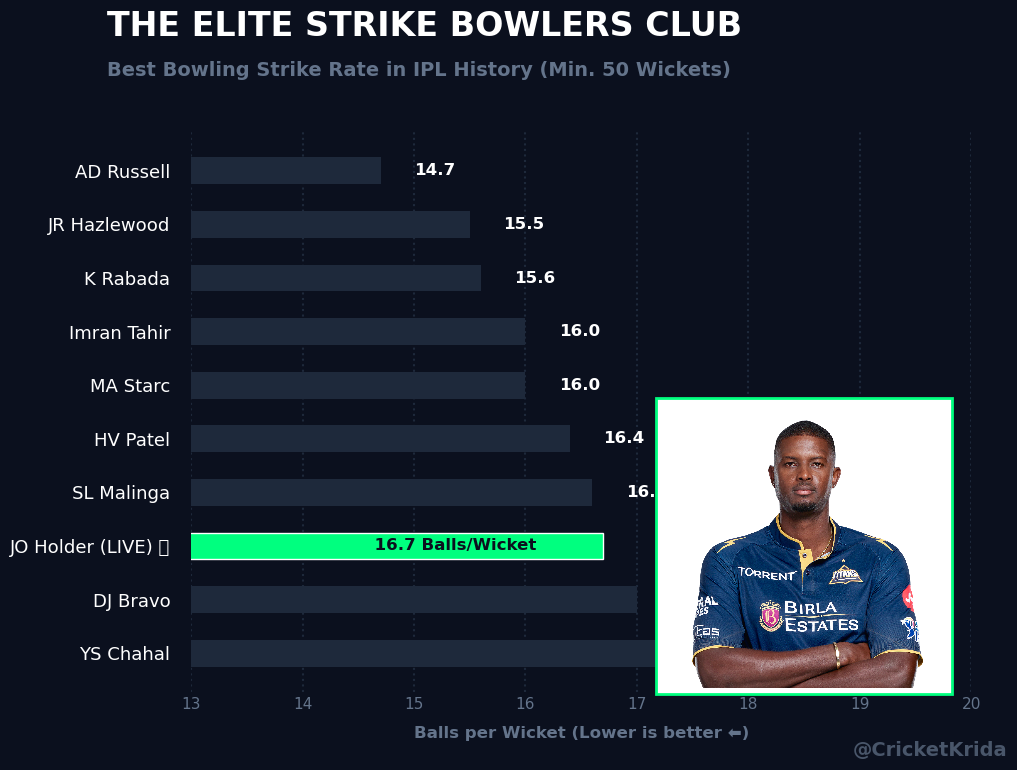

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import os

# 1. Load the Data (Manually injecting Holder to show his rank)
data = {
    'bowler': ['AD Russell', 'JR Hazlewood', 'K Rabada', 'MA Starc', 'Imran Tahir', 
               'HV Patel', 'SL Malinga', 'JO Holder (LIVE) 🚨', 'DJ Bravo', 'YS Chahal'],
    'strike_rate': [14.7, 15.5, 15.6, 16.0, 16.0, 16.4, 16.6, 16.7, 17.0, 17.3] 
}

df = pd.DataFrame(data)
df = df.sort_values(by='strike_rate', ascending=False).reset_index(drop=True) # Descending for horizontal plot

# 2. Setup Premium Plot
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(12, 8))

# Deep rich background
bg_color = '#0B101E' 
fig.patch.set_facecolor(bg_color) 
ax.set_facecolor(bg_color)

# Faint vertical gridlines (helps visualize strike rate gaps)
ax.grid(axis='x', color='#1E293B', linestyle=':', linewidth=1.5, zorder=0)

# 3. Create Custom Colors
# Highlight Holder in Neon Green, others in Slate Gray
colors = ['#00FF7F' if 'Holder' in b else '#1E293B' for b in df['bowler']]
edge_colors = ['#FFFFFF' if 'Holder' in b else 'none' for b in df['bowler']]

# 4. Create the Bars
bars = ax.barh(df['bowler'], df['strike_rate'], color=colors, edgecolor=edge_colors, height=0.5, zorder=3)

# 5. Add Annotations
for i, bar in enumerate(bars):
    width = bar.get_width()
    y = bar.get_y()
    height = bar.get_height()
    bowler = df['bowler'][i]
    
    # Text inside the bar
    if 'Holder' in bowler:
        ax.text(width - 0.5, y + height/2, f"  {width:.1f} Balls/Wicket  ", 
                va='center', ha='right', color='#0B101E', fontsize=12, fontweight='bold')
    else:
        ax.text(width + 0.3, y + height/2, f"{width:.1f}", 
                va='center', color='white', fontsize=12, fontweight='bold')

# ==========================================
# 6. ADDING JASON HOLDER'S AVATAR
# ==========================================
player_name = "JO Holder" # Standard DB naming

img_path = None
if os.path.exists(f"{player_name}.png"):
    img_path = f"{player_name}.png"
elif os.path.exists(f"{player_name}.jpg"):
    img_path = f"{player_name}.jpg"

if img_path:
    try:
        arr_img = plt.imread(img_path)
        imagebox = OffsetImage(arr_img, zoom=0.2) # Adjust zoom if needed
        imagebox.image.axes = ax
        
        # Place avatar near his specific bar!
        # Find the Y-coordinate of Holder's bar
        holder_y_index = df[df['bowler'].str.contains('Holder')].index[0]
        
        ab = AnnotationBbox(imagebox, (18.5, holder_y_index), 
                            xycoords='data', 
                            frameon=True, 
                            bboxprops=dict(edgecolor='#00FF7F', linewidth=2))
        ax.add_artist(ab)
    except Exception as e:
        print(f"Could not load image: {e}")
# ==========================================

# 7. Premium Typography & Titles
fig.text(0.13, 0.94, "THE ELITE STRIKE BOWLERS CLUB", 
         color='white', fontsize=24, fontweight='900', fontfamily='sans-serif')

fig.text(0.13, 0.89, "Best Bowling Strike Rate in IPL History (Min. 50 Wickets)", 
         color='#64748B', fontsize=14, fontweight='bold', fontfamily='sans-serif')

# 8. Axis Styling
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

# Lower strike rate is better, so let's set limits nicely
ax.set_xlim(13, 20)
ax.set_xlabel("Balls per Wicket (Lower is better ⬅️)", color='#64748B', fontsize=12, fontweight='bold', labelpad=10)
ax.tick_params(axis='y', length=0, labelsize=13, colors='white', pad=15)
ax.tick_params(axis='x', length=0, labelsize=11, colors='#64748B')

# Watermark
fig.text(0.88, 0.04, '@CricketKrida', fontsize=14, color='#64748B', alpha=0.7, ha='right', fontweight='bold')

plt.subplots_adjust(top=0.82, bottom=0.12, left=0.2, right=0.85)
plt.savefig('holder_strike_rate.png', dpi=300, bbox_inches='tight')
plt.show()